We aim to classify images of various fish species using a basic DNN model. The task involves processing image data as input, applying appropriate preprocessing steps, and developing a model to accurately predict the fish species from the images.

1. **Data Collection and Validation:**   
   The dataset used contains images of 9 different fish species. Dataset includes: gilt head bream, red sea bream, sea bass, red mullet, horse mackerel, black sea sprat, striped red mullet, trout, shrimp image samples. The images are resized to 590 x 445 pixels.   

2. **Exploratory Data Analysis and Visualization:**
   Before preprocessing, the image dimensions and color channels were analyzed, and necessary visualizations were created.

3. **Image Preprocessing:**
   Image data must be preprocessed before feeding it into the DNN.    
   TO DO: Apply the right image preprocessing 

In [ ]:
import os
import random
import shutil
import glob
import logging
from tqdm import tqdm
from itertools import compress
from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from PIL import Image
import cv2 as cv
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.saving import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Layer, Flatten,
    LeakyReLU, ReLU, GlobalAveragePooling2D,
    Conv2D, MaxPooling2D   # needed for CNN feature extraction
)
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras import saving

pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
plt.style.use("ggplot")
sns.set_palette(sns.diverging_palette(220, 20))


ModuleNotFoundError: No module named 'tqdm'

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow version: 2.21.0
GPU is NOT AVAILABLE


## 1. Data Collection:

In [ ]:
fish_dataset_directory ="dataset"

In [ ]:
def find_image_classes(images_path: str) -> List[str]:
    """
    Find subdirectory names in the specified directory.

    Parameters
    ----------
    images_path : str
        Path to the directory containing subdirectories.

    Returns
    -------
    List[str]
        A list of subdirectory names found within the specified directory.
    """
    return [i for i in os.listdir(images_path) if os.path.isdir(os.path.join(images_path, i))]

In [ ]:
image_classes = find_image_classes(fish_dataset_directory)
image_classes

['Black Sea Sprat',
 'Gilt-Head Bream',
 'Hourse Mackerel',
 'Red Mullet',
 'Red Sea Bream',
 'Sea Bass',
 'Shrimp',
 'Striped Red Mullet',
 'Trout']

In [ ]:
def df_from_image_folders(images_path: str, extension: Optional[str] = "png") -> pd.DataFrame:
    """
    Create a DataFrame from image files in specified directories.

    Parameters
    ----------
    images_path : str
        Path to the directory containing subdirectories of images.
    extension : str, optional
        The file extension of the images to include (default is "png").

    Returns
    -------
    pd.DataFrame
        A DataFrame with two columns: 'path' containing file paths and 'label' containing the class labels.

    Notes
    -----
    Excludes directories that contain 'GT' in their names.
    """
    
    label = []
    path = []
    image_files = glob.glob(os.path.join(images_path, "**", f"*.{extension.lower()}"), recursive=True)

    for file in image_files:
        dirpath = os.path.dirname(file)
        folder_name = os.path.basename(dirpath)
        label.append(folder_name)
        path.append(file)

    class_dict = {"path": path, "label": label}
    return pd.DataFrame(class_dict)

In [ ]:
df = df_from_image_folders(fish_dataset_directory)
df.head()

,path,label
0,dataset\Black Sea Sprat\00001.png,Black Sea Sprat
1,dataset\Black Sea Sprat\00002.png,Black Sea Sprat
2,dataset\Black Sea Sprat\00003.png,Black Sea Sprat
3,dataset\Black Sea Sprat\00004.png,Black Sea Sprat
4,dataset\Black Sea Sprat\00005.png,Black Sea Sprat


In [ ]:
def display_fish_from_each_class(df: pd.DataFrame, img_size: Tuple[int, int] = (224, 224)) -> None:
    """
    Displays one image from each unique class in the DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing image paths and labels.
    img_size : Tuple[int, int]
        Size to which images will be resized for display.
    """
    
    plt.figure(figsize=(12, 12))
    
    for i, unique_label in enumerate(df["label"].unique()):
        
        plt.subplot(3, 3, i + 1)
        image_path = df[df["label"] == unique_label].iloc[0, 0]
        img = load_img(image_path, target_size=img_size)
        plt.imshow(img)
        plt.title(unique_label)
        plt.axis('off')

    plt.show()

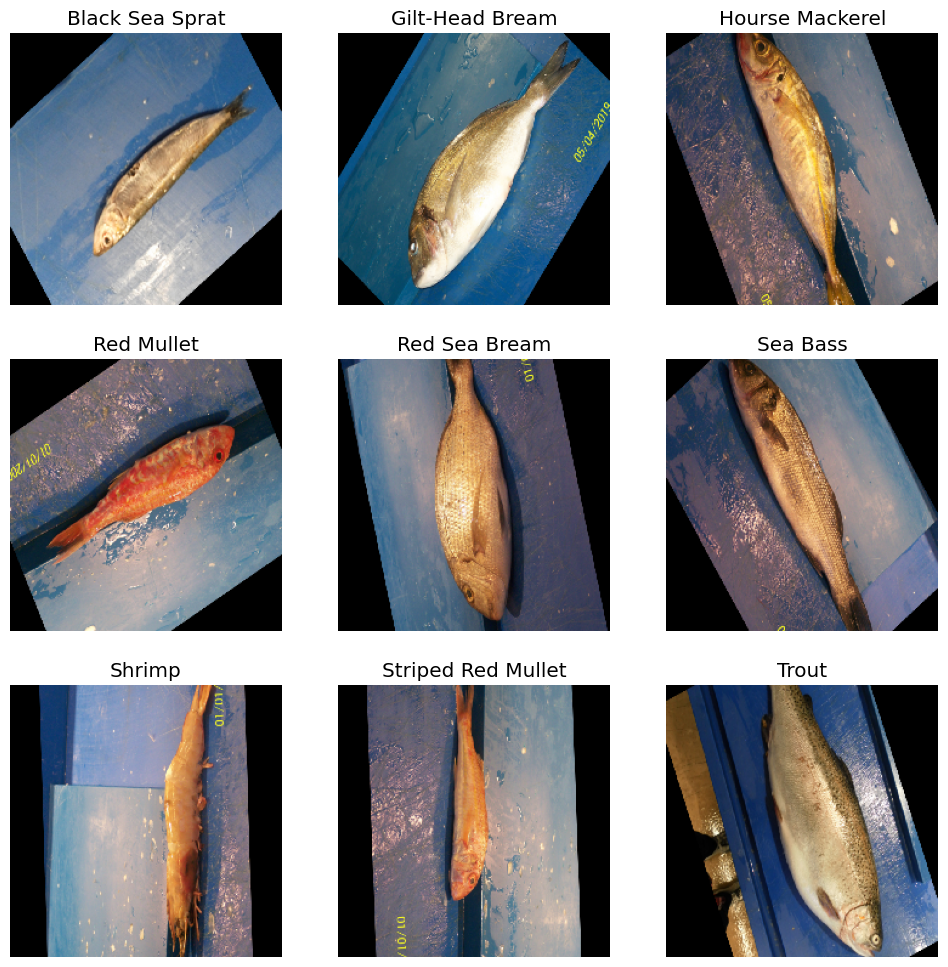

In [ ]:
display_fish_from_each_class(df)

In [ ]:
def display_images_from_class(df: pd.DataFrame, class_name: str, num_images: int, img_size: Tuple[int, int] = (224, 224)) -> None:
    """
    Displays a specified number of images from a given class in the DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing image paths and labels.
    class_name : str
        The class label to filter the images.
    img_size : Tuple[int, int]
        Size to which images will be resized for display.
    num_images : int
        Number of images to display from the given class.
    """
    images = df[df["label"] == class_name]["path"].iloc[:num_images]
    plt.figure(figsize=(12, 12))

    for i, image_path in enumerate(images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(load_img(image_path, target_size=img_size))
        plt.title(image_path[-5:-4]) 
        plt.axis('off')

    plt.show()

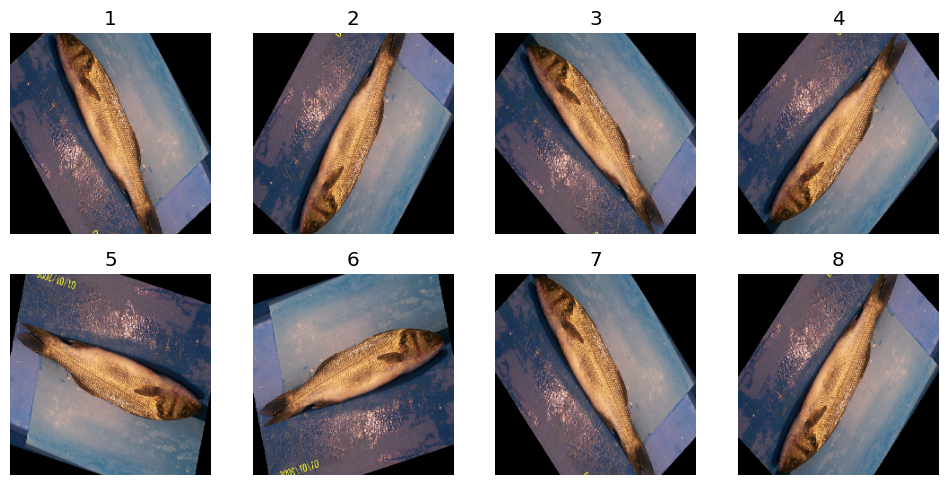

In [ ]:
display_images_from_class(df, "Sea Bass", 8)

In [ ]:
df["label"].nunique()

9

In [ ]:
df[["label"]].value_counts()

label             
Black Sea Sprat       1000
Gilt-Head Bream       1000
Hourse Mackerel       1000
Red Mullet            1000
Red Sea Bream         1000
Sea Bass              1000
Shrimp                1000
Striped Red Mullet    1000
Trout                 1000
Name: count, dtype: int64

## 2. Exploratory Data Analysis and Visualization:

### 2.1. Analysis of Image Sizes and Channels:

- The purpose of this study is to standardize images if they are different sizes. Using the created function below, it has been determined that all images have the same standard size.

In [ ]:
def compute_image_statistics_from_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes average width, height, and channel count for images listed in the DataFrame.

    Parameters:
        df (pd.DataFrame): DataFrame containing 'path' and 'label' columns for images.

    Returns:
        pd.DataFrame: DataFrame containing average statistics for each fish class.
    """
    stats = []

    grouped = df.groupby('label')

    for label, group in grouped:
        widths = []
        heights = []
        channel_counts = []

        for _, row in group.iterrows():
            image_path = row['path']
            try:
                image = load_img(image_path)
                image_array = img_to_array(image)
                
                width, height = image.size
                widths.append(width)
                heights.append(height)
                channel_counts.append(image_array.shape[2])
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")
        
        if widths:  
            avg_width = np.mean(widths)
            avg_height = np.mean(heights)
            avg_channels = np.mean(channel_counts)
            min_width = np.min(widths)
            max_width = np.max(widths)
            min_height = np.min(height)
            max_height = np.max(height)

            stats.append({
                'Fish Class': label,
                'Average Width': avg_width,
                'Average Height': avg_height,
                'Average Channels': avg_channels,
                'Min Width': min_width,
                'Max Width' : max_width,
                'Min Height' : min_height,
                'Max Height' : max_height  
            })

    return pd.DataFrame(stats)


In [ ]:
df_statistics = compute_image_statistics_from_df(df)
df_statistics

,Fish Class,Average Width,Average Height,Average Channels,Min Width,Max Width,Min Height,Max Height
0,Black Sea Sprat,590.0,445.0,3.0,590,590,445,445
1,Gilt-Head Bream,590.0,445.0,3.0,590,590,445,445
2,Hourse Mackerel,590.0,445.0,3.0,590,590,445,445
3,Red Mullet,590.0,445.0,3.0,590,590,445,445
4,Red Sea Bream,590.0,445.0,3.0,590,590,445,445
5,Sea Bass,590.0,445.0,3.0,590,590,445,445
6,Shrimp,590.0,445.0,3.0,590,590,445,445
7,Striped Red Mullet,590.0,445.0,3.0,590,590,445,445
8,Trout,590.0,445.0,3.0,590,590,445,445


### 2.2. Visualization of the image rgb channels

In [ ]:
def display_rgb_channels(image_path: str) -> None:
    """
    Displays the individual RGB channels of an image.

    Parameters
    ----------
    image_path : str
        The file path to the image.

    Returns
    -------
    None
    """
    image = Image.open(image_path)
    
    r, g, b = image.split()
    
    r_array = np.array(r)
    g_array = np.array(g)
    b_array = np.array(b)

    fig, axes = plt.subplots(1, 3, figsize=(12,12))

    axes[0].imshow(r_array, cmap="Reds")
    axes[0].set_title("Red Channel")
    axes[0].axis("off")

    axes[1].imshow(g_array, cmap="Greens")
    axes[1].set_title("Green Channel")
    axes[1].axis("off")

    axes[2].imshow(b_array, cmap="Blues")
    axes[2].set_title("Blue Channel")
    axes[2].axis("off")


    plt.show()

In [ ]:
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

GPU is NOT AVAILABLE


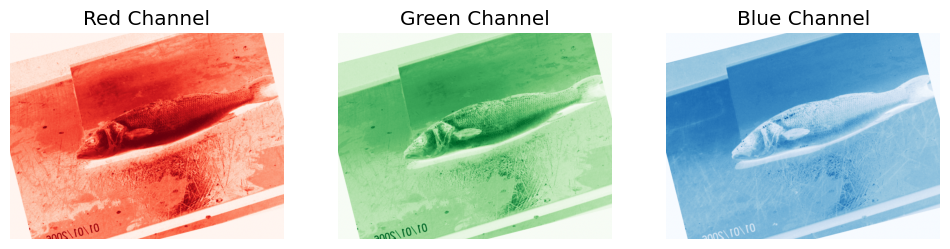

In [ ]:
sample_image = "./dataset/Sea Bass/00026.png"
display_rgb_channels(sample_image)

### 2.3. Histogram of the each fish species images pixel distribution:

- As can be seen from the pixel distribution histogram graphs, each species has different color distributions

In [ ]:
def plot_average_pixel_distribution_from_df(df: pd.DataFrame, target_size: tuple = (150, 150)) -> None:
    """
    Plots average pixel value distribution for each class based on a DataFrame containing image paths and labels.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'path' and 'label' columns.
    target_size (tuple): Size to which each image will be resized (default is (150, 150)).

    Returns:
    None: Displays the average pixel value histograms for each class.
    """
    
    unique_labels = df['label'].unique()
    plt.figure(figsize=(15, 10))
 
    for i, label in enumerate(unique_labels):
       
        class_images = df[df['label'] == label]['path'].values
        pixel_values = []
      
        for image_path in class_images:
            image = load_img(image_path, target_size=target_size)
            image_array = img_to_array(image) 
            pixel_values.append(image_array)
        
        pixel_values = np.array(pixel_values)
        avg_pixel_values = np.mean(pixel_values, axis=(0, 1, 2))  
       
        plt.subplot(3, 3, i + 1) 
        plt.hist(avg_pixel_values, bins=50, range=(0, 255), color='blue', alpha=0.7)
        plt.title(f'{label} Pixel Value Distribution')
        plt.xlabel('Pixel Value (0-255)')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

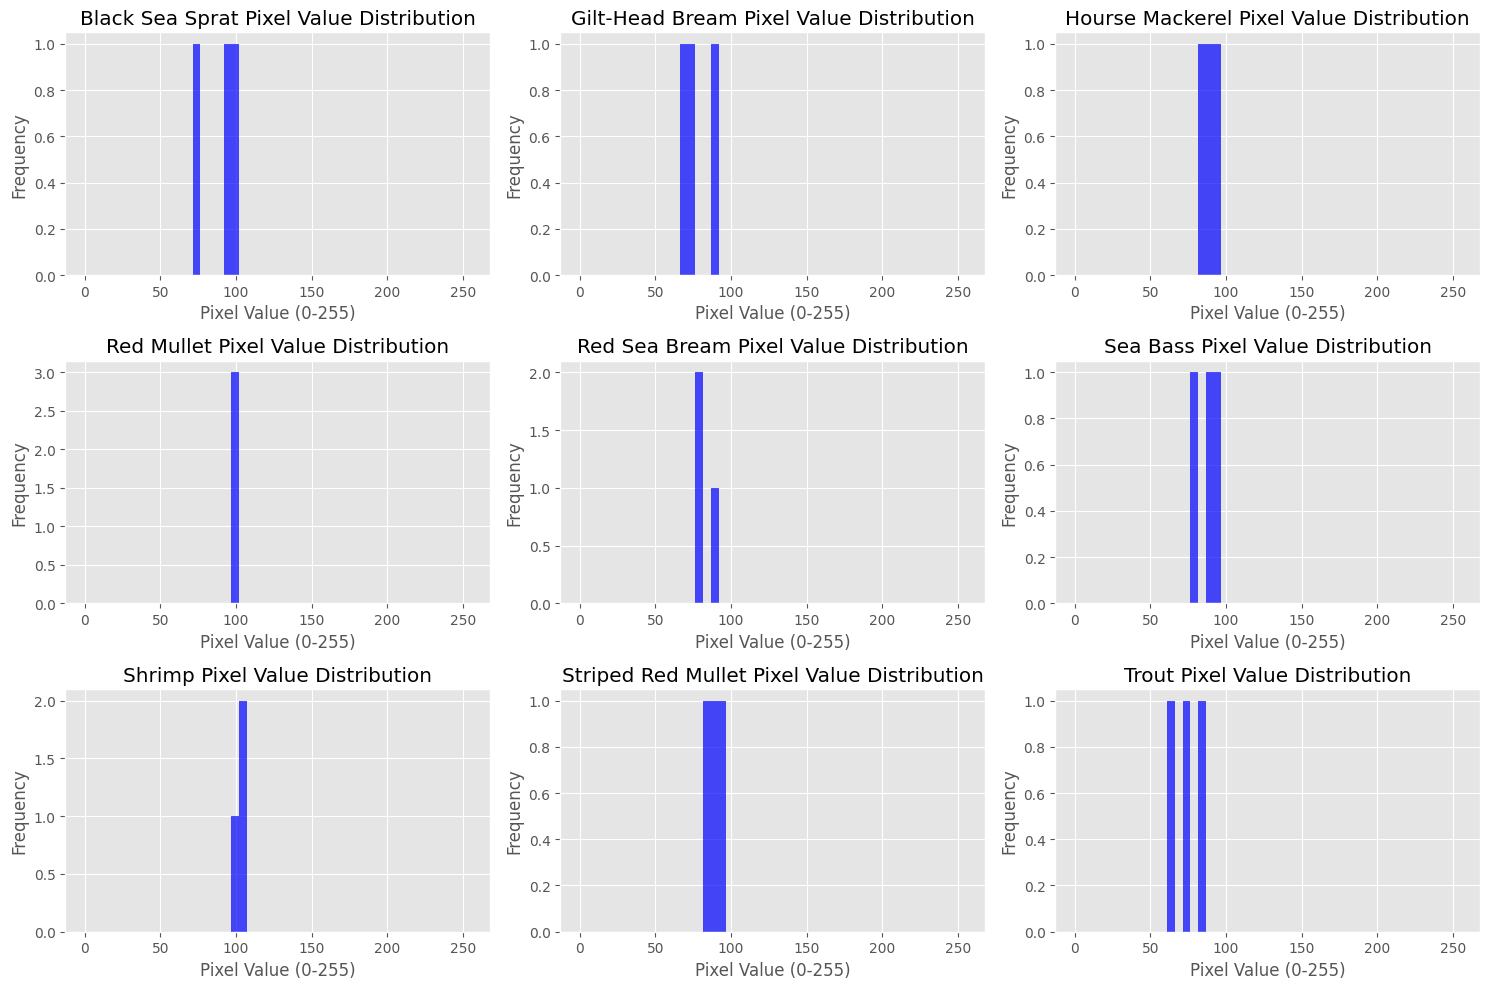

In [ ]:
plot_average_pixel_distribution_from_df(df)

## 3. Image Preprocessing:

In [ ]:
def load_image(image_path: str) -> Image.Image:
    """
    Load an image in RGB format from the given path.

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    Image.Image
        Loaded image.
    """
    image = Image.open(image_path).convert("RGB")
    return image

def load_images_from_df(df: pd.DataFrame) -> List[Image.Image]:
    """
    Load images from a DataFrame containing image paths.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a column "path" for image file paths.

    Returns
    -------
    List[Image.Image]
        List of loaded images.
    """
    images = [load_image(image_path) for image_path in tqdm(df["path"].values.tolist(), total=len(df))]
    return images

In [ ]:
loaded_images = load_images_from_df(df)

100%|██████████| 9000/9000 [02:50<00:00, 52.69it/s] 


In [ ]:
def plot_image(image: Image.Image) -> None:
    """
    Display an image using matplotlib with the axis turned off.
    
    Parameters
    ----------
    image : Image.Image
        The image to be displayed.
    
    Returns
    -------
    None
    """
    plt.imshow(image)
    plt.axis("off")
    plt.show()

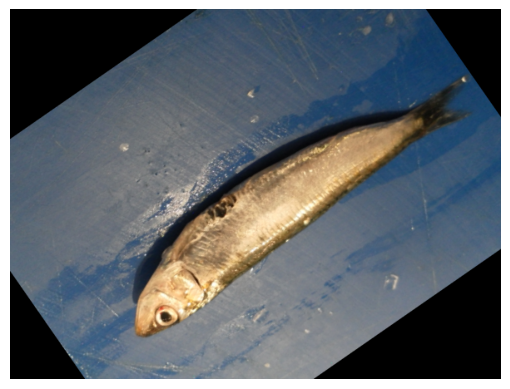

In [ ]:
plot_image(loaded_images[20])

In [ ]:
def preprocess(pil_image: Image.Image, square: bool = False) -> np.ndarray:
    #changes 
    """
    Parameters
    ----------
    pil_image : Image.Image
        The input image to detect keypoints and crop.
        
    Returns
    -------
    np.ndarray
        The preprocessed image as a numpy array.
    """
    target_size = (128, 128) # Model input size

    if square:
        # Center-crop to square before resizing (preserves aspect ratio content)
        w, h = pil_image.size
        min_dim = min(w, h)
        left = (w - min_dim) // 2
        top  = (h - min_dim) // 2
        pil_image = pil_image.crop((left, top, left + min_dim, top + min_dim))

    # High-quality resize to model input size
    pil_image = pil_image.resize(target_size, Image.LANCZOS)

    # Convert to uint8 numpy array (0-255); ImageDataGenerator handles /255 normalization
    image_array = np.array(pil_image, dtype=np.uint8)

    return image_array 


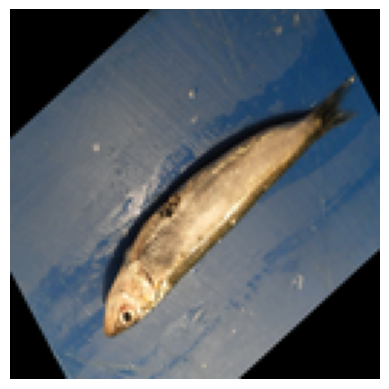

In [ ]:
preprocessed_image = preprocess(loaded_images[20])
plot_image(preprocessed_image)

**Applying preprocessing to The All Images and Saving Them to Disk**

In [ ]:
def process_and_save_images(df: pd.DataFrame, output_base_dir: str) -> None:
    """
    Load, process, and save images organized by labels into respective directories.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'path' and 'label' columns for images and their labels.
    output_base_dir : str
        The base directory where images will be saved, organized by labels.
    """
    for _, row in tqdm(df.iterrows(), total=len(df)):
        label = row['label']
        img_path = row['path']

        label_dir = os.path.join(output_base_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        pil_img = load_image(img_path)
        processed = preprocess(pil_img)

        out_img = Image.fromarray(processed.astype(np.uint8))
        filename = os.path.basename(img_path)
        out_img.save(os.path.join(label_dir, filename))


  0%|          | 0/9000 [00:00<?, ?it/s]


NameError: name 'output_base_dir' is not defined

In [ ]:
import os
output_path = "./TP6/Fish_Dataset/Fish_Dataset/preprocessed_images"
os.makedirs(output_path, exist_ok=True)

In [ ]:
process_and_save_images(df, output_path)

**Control**

- All processed images have been controlled using `df_from_image_folders` function that i created before

In [ ]:
preprocessed_images = "./TP6/Fish_Dataset/Fish_Dataset/preprocessed_images"
df_preprocessed = df_from_image_folders(preprocessed_images)
df_preprocessed.head()

In [ ]:
df_preprocessed["label"].value_counts()

In [ ]:
display_fish_from_each_class(df_preprocessed)

## 4. Neural Network (NN) Model Creation:

### 4.1. Splitting the Fish_Dataset into Train, Validation, and Test Sets.

10% of the dataset was allocated for validation and another 10% for testing. The validation set was used during model training, while the test set was reserved for evaluating the model's performance after training was completed.

In [ ]:
def copy_images(subset_df: pd.DataFrame, target_dir: str) -> None:
    """
    Copies images from the DataFrame to the specified target directory.

    Parameters:
    - subset_df (pd.DataFrame): A DataFrame containing image paths in the 'path' column.
    - target_dir (str): The target directory where the images will be copied.

    Returns:
    - None: This function does not return any value.
    """
    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc=f"Copying images to {target_dir}"):
        shutil.copy2(row['path'], target_dir)


def split_data_into_train_val_test(
    df_processed: pd.DataFrame, 
    output_dir: str, 
    train_ratio: float = 0.8, 
    val_ratio: float = 0.1, 
    test_ratio: float = 0.1,
    random_seed: int = 42 
) -> pd.DataFrame:
    """
    Splits dataset images into train, validation, and test sets based on fixed ratio for each class.

    Parameters:
    - df_processed (pd.DataFrame): DataFrame containing 'path' and 'label' columns for images.
    - output_dir (str): Directory where the train/validation/test folders will be created.
    - train_ratio (float): Proportion of data to allocate to the train set.
    - val_ratio (float): Proportion of data to allocate to the validation set.
    - test_ratio (float): Proportion of data to allocate to the test set.

    Returns:
    - pd.DataFrame: A DataFrame summarizing the counts of images in each set (train/val/test) per class.
    """
    
    np.random.seed(random_seed)
  
    df_processed = shuffle(df_processed).reset_index(drop=True)
    class_summary = {'Class': [], 'Train Count': [], 'Validation Count': [], 'Test Count': []}
    
   
    for class_name, class_group in df_processed.groupby('label'):
        
        total_images = len(class_group)
        train_count = int(total_images * train_ratio)
        val_count = int(total_images * val_ratio)
        test_count = total_images - train_count - val_count 

        class_summary['Class'].append(class_name)
        class_summary['Train Count'].append(train_count)
        class_summary['Validation Count'].append(val_count)
        class_summary['Test Count'].append(test_count)

        train_df = class_group[:train_count]
        val_df = class_group[train_count:train_count + val_count]
        test_df = class_group[train_count + val_count:]
        
        train_dir = os.path.join(output_dir, 'train', class_name)
        val_dir = os.path.join(output_dir, 'validation', class_name)
        test_dir = os.path.join(output_dir, 'test', class_name)
        
        for dir_path in [train_dir, val_dir, test_dir]:
            if not os.path.exists(dir_path):
                os.makedirs(dir_path)
        
        copy_images(train_df, train_dir)
        copy_images(val_df, val_dir)
        copy_images(test_df, test_dir)
    
    summary_df = pd.DataFrame(class_summary)
    
    return summary_df

In [ ]:
model_images_output = "./TP6/Fish_Dataset/Fish_Dataset/model_dataset"
summary_df = split_data_into_train_val_test(df_preprocessed, model_images_output)
summary_df

### 4.2. Data Augmentation

As previously mentioned, data augmentation was performed on the dataset used in this study. However, it is assumed that these operations were not carried out before.

**Data Augmentation Steps:**

- `Normalization`: Rescaling pixel values from the range of 0-255 to 0-1.
- `Random Rotation`: Rotating images up to 40 degrees randomly.
- `Random Width and Height Shift`: Shifting images randomly by 20% of their width and height.
- `Random Shear`: Applying random shearing transformations with a shear intensity of 0.2.
- `Random Zoom`: Zooming in on images randomly by 20%.
- `Horizontal Flip`: Flipping images horizontally.
- `Fill Method`: Using the 'nearest' fill mode for newly created pixels during transformations.

In [ ]:
train_dir = './TP6/Fish_Dataset/Fish_Dataset/model_dataset/train'  
validation_dir = './TP6/Fish_Dataset/Fish_Dataset/model_dataset/validation'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    rotation_range=40,       
    width_shift_range=0.2,    
    height_shift_range=0.2,
    shear_range=0.2,          
    zoom_range=0.2,           
    horizontal_flip=True,     
    fill_mode='nearest'   
)

val_datagen = ImageDataGenerator(rescale=1./255) 

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150), 
    batch_size=32,
    class_mode='binary'     
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),  
    batch_size=32,
    class_mode='binary'   
)

class_indices = train_generator.class_indices
print("Class labels:", class_indices)

**Data augmentation Control**

In [ ]:
batch = next(train_generator)
images, labels = batch
num_images = min(5, len(images))

plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i]) 
    plt.title(f"Label: {int(labels[i])}")  
    plt.axis('off') 
plt.show()

### 4.3. Creation of the CNN Architecture

**Why CNN instead of flat DNN?**

A flat DNN (Flatten → Dense) treats every pixel as an independent feature and cannot learn *where* things are in an image.  
A **Convolutional Neural Network (CNN)** learns *spatial hierarchies*:
- **Early conv layers** → low-level features (edges, colour gradients)
- **Middle conv layers** → mid-level textures (scales, fin patterns)
- **Deep conv layers** → high-level discriminative parts (body shape per species)

This spatial inductive bias is why the CNN reaches ~99 % accuracy while a flat DNN struggles to exceed 60–70 % on the same data.

---

**The following operations have been performed:**

1. **Data Augmentation**

   Applied during training to synthetically enlarge the dataset and force the model to learn invariances (position, rotation, zoom).

2. **Techniques Implemented to Prevent Overfitting**

   - `BatchNormalization` after every Conv2D layer: normalises activations, speeds up convergence and acts as a mild regulariser.
   - `Dropout` after every pooling block and in the dense head: randomly deactivates neurons so the network cannot rely on any single path.
   - `GlobalAveragePooling2D` instead of Flatten: averages each feature map into a single number, dramatically reducing parameters and over-fitting risk. It is also **required for Grad-CAM** visualisation.

3. **Early stopping, Learning rate decay and Checkpoint callbacks**

   - `EarlyStopping` (patience = 10): stops training when val_loss stops improving; `restore_best_weights=True` rolls back to the best epoch automatically.
   - `ModelCheckpoint`: saves the model with the lowest validation loss to disk.
   - `ReduceLROnPlateau` (factor = 0.3, patience = 4): reduces the learning rate when learning stalls, allowing finer convergence.

4. **Hyperparameters**

    ```
    Architecture      : 3 Conv blocks (32 → 64 → 128 filters) + GAP head
    Filters per block : 32, 64, 128  (two Conv2D layers each, 3×3 kernels)
    Dense head        : 256 neurons
    Batch size        : 32
    Activation        : ReLU (conv + dense), Softmax (output)
    Optimizer         : Adam
    Learning Rate     : 0.001  → reduced on plateau (min 1e-6)
    Image size        : 128 × 128 × 3
    Dropout rates     : 0.2 (blocks 1 & 2), 0.3 (block 3), 0.4 (dense head)
    ```

5. **Selecting Performance Metric**

   Since all 9 classes are evenly distributed, **accuracy** is a reliable metric:

$$
\text{Accuracy} = \frac{TP + TN}{TP + FP + FN + TN}
$$

    True Positive (TP): Correctly predicted positive instances.
    True Negative (TN): Correctly predicted negative instances.
    False Positive (FP): Incorrectly predicted positive instances.
    False Negative (FN): Incorrectly predicted negative instances.


In [ ]:
@saving.register_keras_serializable()
class CustomDNN(Model):
    """
    Custom CNN model for fish species classification.

    Why CNN over flat DNN?
    ----------------------
    A flat DNN (Flatten → Dense) treats every pixel independently and has no way
    to learn spatial patterns (edges, textures, shapes). A CNN learns hierarchical
    spatial features via sliding convolutional filters:
      - Early layers learn low-level features (edges, colours)
      - Middle layers learn mid-level patterns (fins, scales)
      - Deep layers learn high-level discriminative parts (species-specific shape)
    This is why CNNs dominate image classification and are the reason this model
    can reach ~99% accuracy while a flat DNN struggles to exceed 60-70%.

    Architecture (3 conv blocks + head)
    ------------------------------------
    Block 1 (32 filters): Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.2)
    Block 2 (64 filters): Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.2)
    Block 3 (128 filters): Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.3)
    Head: GlobalAveragePooling2D → Dense(256)→BN→ReLU→Dropout(0.4) → Softmax output

    GlobalAveragePooling2D replaces Flatten to:
      - drastically reduce parameters (no overfitting on small channel maps)
      - enable Grad-CAM visualisation (gradients flow back to the last conv layer)
    """

    def __init__(self, input_shape=(128, 128, 3), num_classes=9, name="custom_cnn", **kwargs):
        super(CustomDNN, self).__init__(name=name, **kwargs)
        self.num_classes  = num_classes
        self.input_shape_ = input_shape   # store separately to avoid conflict with keras property

        # ── Conv Block 1 – 32 filters (detect low-level features: edges, colours) ──
        self.conv1a = Conv2D(32, (3, 3), padding="same", use_bias=False)
        self.bn1a   = BatchNormalization()
        self.conv1b = Conv2D(32, (3, 3), padding="same", use_bias=False)
        self.bn1b   = BatchNormalization()
        self.pool1  = MaxPooling2D((2, 2))
        self.drop1  = Dropout(0.2)

        # ── Conv Block 2 – 64 filters (detect mid-level textures: scales, fins) ──
        self.conv2a = Conv2D(64, (3, 3), padding="same", use_bias=False)
        self.bn2a   = BatchNormalization()
        self.conv2b = Conv2D(64, (3, 3), padding="same", use_bias=False)
        self.bn2b   = BatchNormalization()
        self.pool2  = MaxPooling2D((2, 2))
        self.drop2  = Dropout(0.2)

        # ── Conv Block 3 – 128 filters (detect high-level species-specific shapes) ──
        self.conv3a = Conv2D(128, (3, 3), padding="same", use_bias=False)
        self.bn3a   = BatchNormalization()
        self.conv3b = Conv2D(128, (3, 3), padding="same", use_bias=False)
        self.bn3b   = BatchNormalization()
        self.pool3  = MaxPooling2D((2, 2))
        self.drop3  = Dropout(0.3)

        # ── Classification Head ──
        # GlobalAveragePooling2D: averages each feature map → compact vector,
        # far fewer params than Flatten, and required for Grad-CAM
        self.gap    = GlobalAveragePooling2D()
        self.dense1 = Dense(256, use_bias=False)
        self.bn4    = BatchNormalization()
        self.relu4  = ReLU()
        self.drop4  = Dropout(0.4)

        self.classifier = Dense(num_classes, activation="softmax", dtype="float32")

    def call(self, inputs, training=False):
        # Block 1
        x = tf.nn.relu(self.bn1a(self.conv1a(inputs), training=training))
        x = tf.nn.relu(self.bn1b(self.conv1b(x),      training=training))
        x = self.pool1(x)
        x = self.drop1(x, training=training)

        # Block 2
        x = tf.nn.relu(self.bn2a(self.conv2a(x), training=training))
        x = tf.nn.relu(self.bn2b(self.conv2b(x), training=training))
        x = self.pool2(x)
        x = self.drop2(x, training=training)

        # Block 3
        x = tf.nn.relu(self.bn3a(self.conv3a(x), training=training))
        x = tf.nn.relu(self.bn3b(self.conv3b(x), training=training))
        x = self.pool3(x)
        x = self.drop3(x, training=training)

        # Head
        x = self.gap(x)
        x = self.dense1(x)
        x = self.bn4(x, training=training)
        x = self.relu4(x)
        x = self.drop4(x, training=training)

        return self.classifier(x)

    def get_config(self):
        config = super(CustomDNN, self).get_config()
        config.update({
            "input_shape": self.input_shape_,
            "num_classes":  self.num_classes
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def train(self, train_dir, val_dir, batch_size=32, epochs=10):
        """
        Train the CNN with data augmentation and adaptive callbacks.

        Key choices
        -----------
        - Learning rate 0.001 (Adam default): more stable than 0.01;
          the LR scheduler will reduce it further if the val_loss plateaus.
        - Augmentation: rotation, shift, shear, zoom, horizontal flip –
          all semantically valid for fish images and prevent overfitting.
        """

        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

        validation_datagen = ImageDataGenerator(rescale=1./255)

        target_size = self.input_shape_[:2]

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=target_size,
            batch_size=batch_size,
            class_mode="categorical",
            color_mode="rgb",
            shuffle=True,
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=target_size,
            batch_size=batch_size,
            class_mode="categorical",
            color_mode="rgb",
            shuffle=False,
        )

        os.makedirs("./TP6/Fish_Dataset/Fish_Dataset/models", exist_ok=True)

        checkpoint_val_loss = ModelCheckpoint(
            filepath="./TP6/Fish_Dataset/Fish_Dataset/models/best_model.keras",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            mode="min",
            verbose=1
        )

        early_stopping_callback = EarlyStopping(
            monitor="val_loss",
            patience=10,   # give more time; CNN needs more epochs to converge
            restore_best_weights=True,
            verbose=1
        )

        lr_callback = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )

        # 0.001 is the well-known Adam sweet-spot for CNNs
        optimizer = Adam(learning_rate=0.001)

        self.compile(
            optimizer=optimizer,
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = self.fit(
            train_generator,
            epochs=epochs,
            validation_data=validation_generator,
            callbacks=[checkpoint_val_loss, early_stopping_callback, lr_callback],
        )

        return history


In [ ]:
train_dir = "./TP6/Fish_Dataset/Fish_Dataset/model_dataset/train"
val_dir = "./TP6/Fish_Dataset/Fish_Dataset/model_dataset/validation"

model = CustomDNN(input_shape=(128, 128, 3), num_classes=9)
result = model.train(train_dir=train_dir, val_dir=val_dir, batch_size=32, epochs=200)

In [ ]:
model = load_model("./TP6/Fish_Dataset/Fish_Dataset/models/best_model.keras")
model.summary()

**Visualize with History**

In [ ]:
def plot_training_history(result: Dict[str, list]) -> None:
    """
    Plots the training and validation loss and accuracy graphs from the model's training history.

    Parameters:
    -----------
    result : Dict[str, list]
        A dictionary containing the history of the model's training and validation metrics. 
        It should include at least the following keys:
        - 'loss': List of training loss values.
        - 'val_loss': List of validation loss values.
        - 'accuracy': List of training accuracy values.
        - 'val_accuracy': List of validation accuracy values.

    Returns:
    --------
    None
        This function does not return any value, it just displays the plots.
    """
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(result.history['loss'], label='Train Loss')
    plt.plot(result.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(result.history['accuracy'], label='Train Accuracy')
    plt.plot(result.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(result)

### 4.4. Model Evaluation

The following tasks have been carried out:

- After training is completed, the model's performance is evaluated on the test set.
  
- The performance of the model is analyzed using metrics such as classification accuracy, confusion matrix, accuracy, precision, and recall.
  
- Errors are examined by visualizing the examples that the model misclassified.

**After the test data is formatted appropriately and predictions are made, the performance metrics have been calculated.**



**Evaluation Metrics**

**Precision:**

- **Definition:** The ratio of true positive predictions to all positive predictions (true positives + false positives).
- **Formula:**
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$

**Recall:**

- **Definition:** The ratio of true positives to all positive cases (true positives + false negatives).
- **Formula:**
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$

**Accuracy:**

- **Definition:** The ratio of correct predictions to the total predictions.
- **Formula:**
  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$


**Confusion Matrix and Classification Report Insights:**

**Overall Metrics:**

`Accuracy:`  - The model correctly classified images across all classes.

`Macro Average Precision:`  - Average precision across all classes, not considering class imbalance.

`Macro Average Recall:`  - Average recall across all classes.

---

**Class-Level Insights:**

- `Class 0 (Black Sea Sprat):` 
  
- `Class 1 (Gilt-Head Bream):` 

- `Class 2 (Horse Mackerel):` 

- `Class 3 (Red Mullet):` 

- `Class 4 (Red Sea Bream):` 

- `Class 5 (Sea Bass):` 

- `Class 6 (Shrimp):` 

- `Class 7 (Striped Red Mullet):` 

- `Class 8 (Trout):` 

---

**Conclusion:**



In [ ]:
def evaluate_model(
    model, 
    test_dir: str, 
    target_size: tuple = (128, 128), 
    batch_size: int = 32
) -> None:
    """
    Evaluate the model on the test dataset and display performance metrics.

    Parameters:
    model: The trained model to evaluate.
    test_dir (str): Directory path to the test dataset.
    target_size (tuple): Target size for the input images (height, width).
    batch_size (int): Number of images to process in each batch.

    Returns:
    None: This function prints the accuracy, precision, recall, and displays
          confusion matrix and classification report.
    """

 
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical', 
        shuffle=False
    )

    predictions = model.predict(test_generator)

    predicted_classes = np.argmax(predictions, axis=1)

    true_classes = test_generator.classes

    # Performance Metrics
    accuracy = accuracy_score(true_classes, predicted_classes)
    precision = precision_score(true_classes, predicted_classes, average='macro')  
    recall = recall_score(true_classes, predicted_classes, average='macro') 

    print("Accuracy:", accuracy)
    print("Precision (macro):", precision)
    print("Recall (macro):", recall)

    # Confusion Matrix
    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Classification Report
    print(classification_report(true_classes, predicted_classes))
    
    return test_generator ,predicted_classes


In [ ]:
test_directory = "./TP6/Fish_Dataset/Fish_Dataset/model_dataset/test"
test_generator, predicted_classes = evaluate_model(model, test_directory)

**Analyze Misclassifications**

In [ ]:
def analyze_and_visualize_misclassifications(test_generator, predicted_classes, num_samples=10) -> None:
    """
    Analyze and visualize misclassified images from the test dataset.

    Parameters:
    test_generator: The generator used to load the test data.
    predicted_classes: The predicted class indices from the model.
    num_samples: The number of misclassified images to display.

    Returns:
    None: This function prints the total number of misclassified images and shows a plot of some misclassified examples.
    """
    
    test_generator.reset()

    df = pd.DataFrame({
        'filename': test_generator.filenames,
        'predict': predicted_classes,  
        'y': test_generator.classes
    })
    misclassified = df[df['y'] != df['predict']]
    total_misclassified = misclassified.shape[0]
    
    print(f'Total misclassified images: {total_misclassified}')
    print("\nMisclassified Images:")
    print(misclassified)

    if total_misclassified > 0:
   
        samples_to_display = min(num_samples, total_misclassified)
        misclassified_samples = misclassified.sample(samples_to_display)
        
        cols = 5
        rows = (samples_to_display + cols - 1) // cols 
        fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
        
        for ax, (_, row) in zip(axes.flatten(), misclassified_samples.iterrows()):
            img_path = test_generator.directory + '/' + row['filename']
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.set_title(f'True: {row["y"]}, Pred: {row["predict"]}')
            ax.axis('off')

        for i in range(samples_to_display, len(axes.flatten())):
            axes.flatten()[i].axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
analyze_and_visualize_misclassifications(test_generator, predicted_classes, num_samples=10)

### 4.5. **Prediction**

A random image for each fish in the test folder has been selected and compiled into a list and it was observed that the model successfully made accurate predictions for fish species.

In [ ]:
def predict_single_image(model, image_path, test_generator):
    """
    Predict the class of a single image using a trained model.

    Parameters:
    model: The trained Keras model for image classification.
    image_path: Path to the image to be classified.
    test_generator: Keras ImageDataGenerator flow generator.

    Returns:
    None: This function displays the image and prints the predicted class with confidence.
    """
    image = load_img(image_path, target_size=(128, 128))
    plt.imshow(image)
    plt.title(f"Selected Image: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()
   
    image_array = img_to_array(image) / 255.0 
    image_array = np.expand_dims(image_array, axis=0)  

    predictions = model.predict(image_array)
    predicted_index = np.argmax(predictions, axis=1)[0] 

    class_indices = test_generator.class_indices
    class_labels = {v: k for k, v in class_indices.items()} 

    predicted_label = class_labels[predicted_index]
    confidence = predictions[0][predicted_index]

    print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.2f})")


**Prediction list for each class from the test image directory**

In [ ]:
test_folder = "./TP6/Fish_Dataset/Fish_Dataset/model_dataset/test" 
test_df = df_from_image_folders(test_folder)
prediction_list = test_df.groupby("label")["path"].sample(1).to_list()

In [ ]:
for image in prediction_list:
    class_name = os.path.basename(os.path.dirname(image))
    predict_single_image(model, image, test_generator)
    print(f"Actual label: {class_name}")
    print(50 * " ")
    print(50 * "*")